In [1]:
! pip install -e .
!pip install geodatasets

Obtaining file:///home/jovyan/Precipitation_paper
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for precip_helper (pyproject.toml) ... done
  Created wheel for precip_helper: filename=precip_helper-0.1.0-0.editable-py3-none-any.whl size=1298 sha256=f58b231cc68d70e001bff62d065e402d87dee7a9a977e3843ad40c9d5d545e55
  Stored in directory: /tmp/pip-ephem-wheel-cache-ak9h11s5/wheels/0d/d8/f6/0e90ec4164bf3c02bf3bed8ede68ddfb64e3b2ef0023ebb734
Successfully built precip_helper
  Attempting uninstall: precip_helper
    Found existing installation: precip_helper 0.1.0
    Uninstalling precip_helper-0.1.0:
      Successfully uninstalled precip_helper-0.1.0


In [2]:
import xarray as xr
import earthaccess
import boto3
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import warnings
from IPython.display import display, Markdown
import pandas as pd
import geopandas as gpd
import rasterio
import datetime
import pyarrow as pa
import pyarrow.parquet as pq
import os
import numpy as np

warnings.filterwarnings('ignore')
%matplotlib inline

%load_ext autoreload
%autoreload 2


from precip_helper.utils import read_in_fires_and_precip

In [3]:
fires = read_in_fires_and_precip()


Subsetting fires by removing Great Plains ecoregion.


In [4]:
# how many days a fire last figure

# how many times does it rain as a %? pre, 1 time, 2 times, 3 times, 4, times, final increment, immediatly after,

<Axes: >

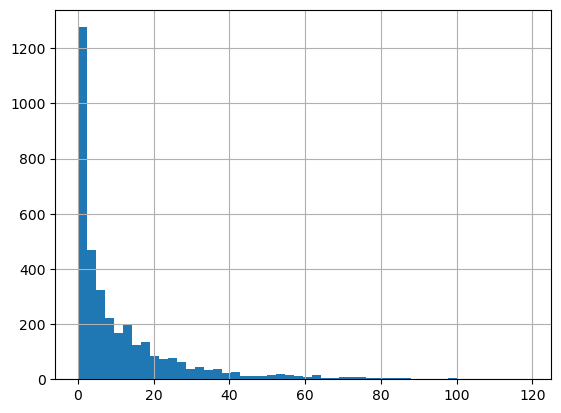

In [5]:
fires.groupby("UfireID").duration.max().hist(bins = 50)



In [6]:
thresh = 1


fires.loc[:, f'precip_over_thresh_{str(thresh)}'] = fires.precipitation >= thresh



Text(0, 0.5, 'number of fires')

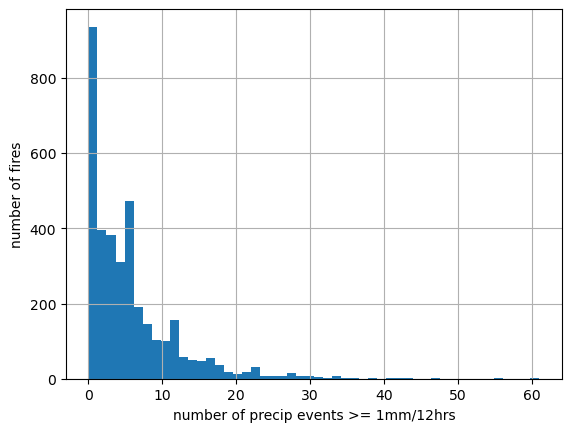

In [7]:
fires.groupby("UfireID")[f'precip_over_thresh_{str(thresh)}'].sum().hist(bins = 50) 
plt.xlabel(f"number of precip events >= {thresh}mm/12hrs") # 91.186 mm over 12 hours is severe rain
plt.ylabel("number of fires")


## Upperish limit on rain = 1.5 inches/hour is a lot of rain. 36.75mm/hr in mm/12 hours that is (25.4 * 1.5 * 12) = 457.2 mm/12 hours https://www.weather.gov/lox/rainrate
## by 0.25 in/hr or 6.35mm/hr , 76.19 mm/12hr you want an umbrella. 
## "spitting" is 0.05 inches/hour or 1.225mm/hr or 15.24 mm/12 hours. It's a bit weird because it's cummulative accross 12 hours. 


<Axes: >

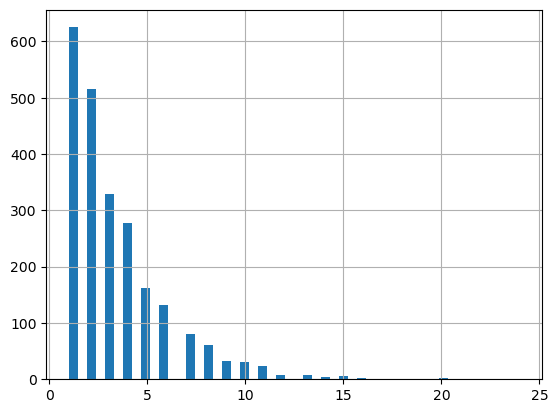

In [8]:
precip_level = 7

fires[fires.precipitation >= precip_level].groupby("UfireID").UfireID.count().hist(bins = 50) ## Looks liek ~ 625 fires have one instance of a precip event of 7 or more. Going with that to start off




In [13]:
# tmp = fires[fires.fr_active_status == "during_fire"].groupby("UfireID")[f'precip_over_thresh_{str(thresh)}'].sum().reset_index(drop = True)

# fires = fires.merge(tmp, on = "UfireID")

In [14]:
# fires[fires.precip_over_thresh_y > 30].l1_ecoregion.unique()

AttributeError: 'GeoDataFrame' object has no attribute 'precip_over_thresh_y'

In [15]:
#fires[(fires.precip_over_thresh_y > 30) & (fires.duration == 22.5)].UfireID #58842_2016 

foo = fires[fires.UfireID == "58842_2016"]

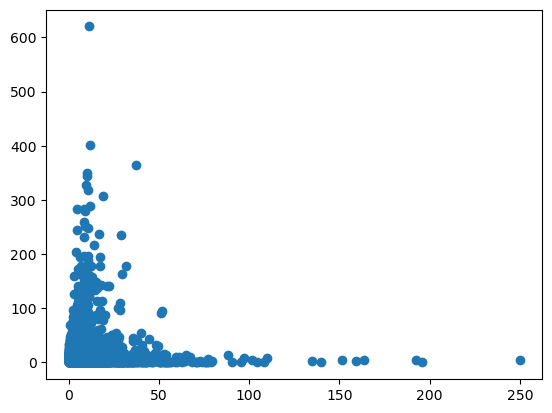

In [16]:
plt.scatter(fires.groupby("UfireID").area_growth_at_t_km2.sum() /fires.groupby("UfireID").duration.max(), fires.groupby("UfireID").precipitation.sum()/ fires.groupby("UfireID").duration.max())

Text(0.5, 0, 'cummulative area')

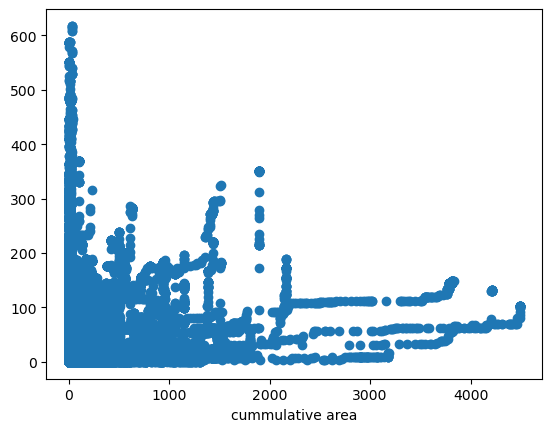

In [17]:
plt.scatter(fires.groupby("UfireID").area_growth_at_t_km2.cumsum(), fires.groupby("UfireID").precipitation.cumsum())
plt.xlabel("cummulative area")
#tmp = fires[fires.UfireID == "9982_2019"]

Text(0, 0.5, 'cumulative precip')

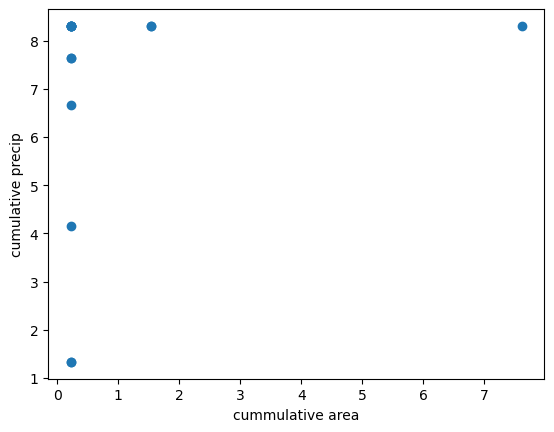

In [18]:
tmp = fires[fires.UfireID == '9982_2019']


plt.scatter(tmp.area_growth_at_t_km2.cumsum(), tmp.precipitation.cumsum())
plt.xlabel("cummulative area")
plt.ylabel("cumulative precip")

Text(0, 0.5, 'cumulative precip')

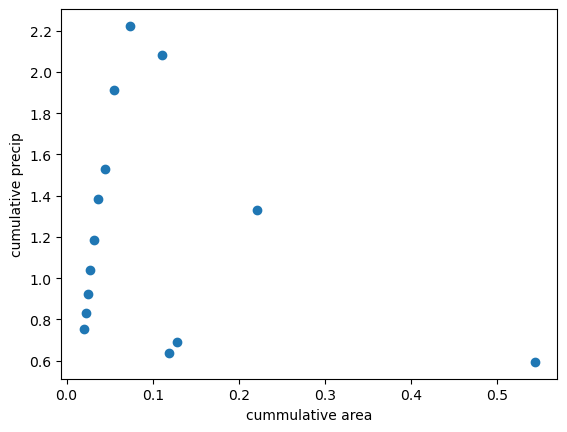

In [19]:
plt.scatter(tmp.area_growth_at_t_km2.cumsum()/tmp.start_off_12hrs, tmp.precipitation.cumsum()/tmp.start_off_12hrs)
plt.xlabel("cummulative area")
plt.ylabel("cumulative precip")

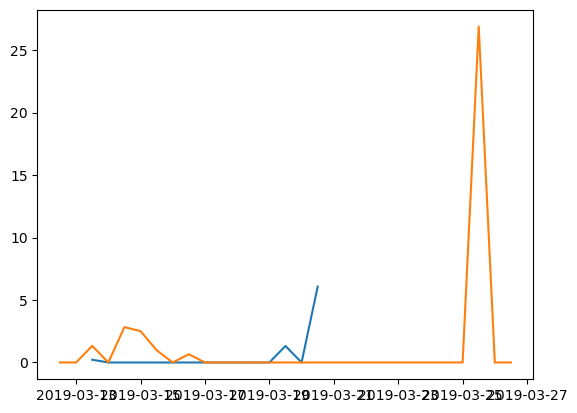

In [20]:
plt.plot(tmp.t, tmp.area_growth_at_t_km2)
plt.plot(tmp.t, tmp.precipitation)

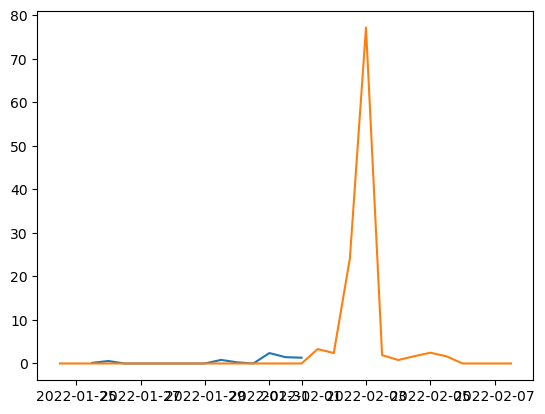

In [21]:
#tmp2 = fires[fires.UfireID == "10138_2013"] # NO precip
#tmp2 = fires[fires.UfireID == "10073_2022"] # NO precip
tmp2 = fires[fires.UfireID == "5047_2022"] # Has precip! Kind of a lot though

plt.plot(tmp2.t, tmp2.area_growth_at_t_km2)
plt.plot(tmp2.t, tmp2.precipitation)

In [57]:
### Jim's sampling scheme (rain before and after event)

thresh = 7

fires.loc[:, f"precip_over_{str(thresh)}"] = fires.precipitation >= thresh
# Odd: fine, no need to go back 24 hours pd.Timedelta(hours = 36) % pd.Timedelta(hours = 12)
# even: bad. need to go back 24 hours pd.Timedelta(hours = 48) % pd.Timedelta(hours = 12)
# zero: bad. no data to sample in that time period. Fail quietly? 
def sample_pre_post_precip(df2, thresh = thresh, min_number = 0.001):
    UfireID = df2.name
    #print(df.columns)
    #print(df.index)
    #df = df.reset_index()
    #print(df['UfireID'])
    df = df2[df2.fr_active_status == "during_fire"] # Not looking at fire ending events right now. Could change
    #print(df.name)
    event_starts = df[f"precip_over_{thresh}"] & ~df[f"precip_over_{thresh}"].shift(1, fill_value=False)
    event_ends = df[f"precip_over_{thresh}"] & ~df[f"precip_over_{thresh}"].shift(-1, fill_value=False)
    start_indices = df[event_starts].t
    end_indices = df[event_ends].t
    no_precip = False
    
    if(len(df[df.precipitation >= thresh]) == 0):
        no_precip = True

    #print(len(df.UfireID.unique()))
    #print(df)
    fire_area_samples = []
    
    # Want a record of fires with no precip, and fires with some "in between" situation, to check for bias
    #print(df["UfireID"].unique())
    fire_area_samples.append({
            'event_start': np.nan,
            'event_end': np.nan,
            'before_sample_fire_area': np.nan, 
            'after_sample_fire_area': np.nan,
            'ratio': np.nan,
            'len_precip': np.nan,
            'precip_sum': np.nan,
            'is_even_number_of_periods': np.nan, 
            'fire_t_len_12_hours': df.t.nunique(), 
            'UfireID': UfireID, #df.UfireID.unique(),
            'no_precip': no_precip,
            'is_rand_period_identical_to_sample_period': np.nan,
            'rand_before_sample_fire_area': np.nan,
            'rand_after_sample_fire_area': np.nan,
            'rand_ratio': np.nan,
            'rand_precip_sum': np.nan
    })
    #num_rain_events = 0
    for start, end in zip(start_indices, end_indices):
        if (start == end):
            continue
        print(start)
        print(end)
        lenght_rain = end - start
        print(lenght_rain)
        is_even_number_of_periods = ((lenght_rain.total_seconds() / pd.Timedelta(hours = 12).total_seconds()) % 2) == 0

        if (is_even_number_of_periods):
            window_size = pd.Timedelta(hours=24) ## need to sample an AM increment and a PM increment, because of different levels of detection sensitivity across the two
        else:
            window_size = pd.Timedelta(hours=12) # pre and post will compare like vs like (AM to AM, or PM to PM)

        
        # Define the windows (exclusive of the event itself)
        # Period before: [start - window] to [start - 1 timestep]
        
        period_before = df[((df.t >= (start - window_size)) & (df.t <= (start - pd.Timedelta(hours=12))))] ## Need to figure out how to do cummulative indexing for 1 or two 12 hour increments
        
        # Period after: [end + 1 timestep] to [end + window]
        period_after = df[(df.t <= (end + window_size))  & (df.t >= (end + pd.Timedelta(hours=12)))] 
        
        # Cases to discard: all cases where can't get a 1:1 comparison. This will throw out *a lot* of small fires
        if(is_even_number_of_periods & (len(period_before) < 2)): # Cases where need 24 hours for even sampleing, but don't have them (start or end)
            continue
        if(is_even_number_of_periods & (len(period_after) < 2)):
            continue
        if((len(period_before) == 0 ) or (len(period_after) == 0)): # Cases where nothing actaully fulfills criteria (no non-rain time to sample)
            continue

        if(any(period_before.precipitation >= thresh) or any(period_after.precipitation >= thresh)): # Case where the "post 24 hours" includes another rain event
            continue

        #num_rain_events = num_rain_events + 1

        ### sample from fire randomly
        t_rand_st = df[((df.t >= (df.t.min() + window_size))) & (df.t <= (df.t.max() - (window_size + (lenght_rain - pd.Timedelta(hours = 12))) ) )].t.sample()## Give me a random-ish t, that has enough data before or after it to sample. 
        t_rand_st = t_rand_st.iloc[0]
        t_rand_end = t_rand_st + (lenght_rain - pd.Timedelta(hours = 12)) ## match length of period with rain ## Does this force the end to be the same as the start if len rain == 1 and window = 1?
        t_rand_end = t_rand_end.iloc[0]
        print(type(t_rand_st))
        print(print(t_rand_end))
        
        rand_period = df[(df.t >= t_rand_st) & (df.t <= t_rand_end)]
        period_before_rand = df[(df.t >= (t_rand_st - window_size) ) & (df.t < t_rand_st)]
        period_after_rand = df[(df.t > t_rand_end) & (df.t <= (t_rand_end + window_size))]

        if((period_before_rand.t.min() == period_before.t.min()) & (period_after_rand.t.min() == period_after.t.min())):
            is_rand_period_identical_to_sample_period = True
        else:
            is_rand_period_identical_to_sample_period = False
        

        ## I thought about this, but AFAIK this really forces the "random sample" to be the same as the rain sample for many lengths of fires. So for example, and 8-period fire with 4 rain days the sample is forces to be the same as the rain days, becase I am also forcing only sampling the rain in the middle of the fire. 
        # I am shelving this effort and instead focusing on sampling:
        # - nigh-night differences. Same as above??? (worse because throw out way more info?
        # - rarer rain frequencies. 
        # - only first rain 
        # - Maybe I should just try it out. 
        
        
        
        fire_area_samples.append({
            'event_start': start,
            'event_end': end,
            'before_sample_fire_area': period_before.area_growth_at_t_km2.sum() + min_number, ## adding small value to prevent division by zero
            'after_sample_fire_area': period_after.area_growth_at_t_km2.sum() + min_number,
            'ratio': (period_before.area_growth_at_t_km2.sum() + min_number) / (period_after.area_growth_at_t_km2.sum() + min_number),
            'len_precip': lenght_rain/ pd.Timedelta(hours = 12),
            'precip_sum': df[(df.t >= start) &  (df.t <= end)].precipitation.sum(),
            'is_even_number_of_periods': is_even_number_of_periods, 
            'fire_t_len_12_hours': df.t.nunique(), 
            'UfireID':UfireID,  #df.UfireID.unique(),
            'no_precip': no_precip,
            'is_rand_period_identical_to_sample_period': is_rand_period_identical_to_sample_period,
            'rand_before_sample_fire_area': period_before_rand.area_growth_at_t_km2.sum() + min_number,
            'rand_after_sample_fire_area': period_after_rand.area_growth_at_t_km2.sum() + min_number,
            'rand_ratio': (period_before.area_growth_at_t_km2.sum() + min_number) / (period_after.area_growth_at_t_km2.sum() + min_number),
            'rand_precip_sum': df[(df.t >= t_rand_start) &  (df.t <= t_rand_end)].precipitation.sum()
            
        })

    new_df = pd.DataFrame(fire_area_samples)
    return(new_df)
        
        
        

        
    

In [58]:
fires.columns = fires.columns.str.strip()


test = pd.DataFrame(fires[[ 't', 'area_growth_at_t_km2',
       'UfireID',  'precipitation', 
       'duration', 'fr_active_status', f"precip_over_{str(thresh)}"]]).groupby("UfireID",  as_index=False).apply(sample_pre_post_precip)

2017-02-13 12:00:00
2017-02-14 12:00:00
1 days 00:00:00
2022-01-08 12:00:00
2022-01-09 00:00:00
0 days 12:00:00


AttributeError: 'Timestamp' object has no attribute 'iloc'

In [ ]:
# # def try_jims_sampleing_method(df, thresh):
# #     df = df[df.fr_active_status.isin(["post_fire", "during_fire"])] ## exclude precip before see fire
# #     if(len(df[df.precipitation >= thresh]) == 0):
# #         #t_precip_min = df[df.fr_active_status == "post_fire"].t.max()
# #         return([])
# #     t_precip_min = df[df.precipitation >= thresh ].t.min() ## First time over threshold
# #     t_vals = df[df.precipitation >= thresh ].t.unique()
# #     if((len(t_vals) ==1) & (t_vals[0] == t_precip_min)):
# #         t_max = df.t.max()


# def area_ratio_pre_post(df, thresh):
#     df = df[df.fr_active_status == 'during_fire']
#     if(len(df[df.precipitation >= thresh]) == 0): ## No rain over threshold
#         #t_precip_min = df[df.fr_active_status == "post_fire"].t.max()
#         return([])
#         t_vals = df[df.precipitation >= thresh ].t.unique()
#         n_steps_rain = 1
#         n_steps_growth_increment = 1

#         # ex = pd.DataFrame({"t": rain_days.t, "12_hour_fr_st": (rain_days.t.diff() > pd.Timedelta(hours = 12)), "12_hour_fr_end": (rain_days.t.diff(-1).abs() > pd.Timedelta(hours = 12))})
#         #sample_mask = df[df.precipitation >= thresh].t.diff() > pd.Timedelta(hours = 12) ## identifyies fire growth timesteps where can do the sampleing 
#         rain_days = pd.concat([df[df.precipitation >= thresh], df[df.t == df.t.min()], df[df.t == df.t.max()]])
#         rain_days = rain_days.sort_values(by = "t")

#         over_12_hours_from_start_mask = (rain_days.t.diff() > pd.Timedelta(hours = 12))
#         over_12_hours_from_end_mask = (rain_days.t.diff(-1).abs() > pd.Timedelta(hours = 12))
        
#         # for t in t_vals:
#         #     prev_t = t - pd.Timedelta(hours = 12)
#         #     post_t = t + pd.Timedelta(hours = 12)
#         #     if(len(df[df.t.isin(prev_t)]) == 0): ## the rain started right when the fire did. 
#         #         return([])
#         #     if(len(df[df.t.isin(post_t)]) == 0): ## The rain is the final part of the timeseries
#         #         return([])

#         #     if(len(df[(df.precipitation >= thresh) & df.t.isin([post_t])].t) < 0): ## The rain went for multiple days.
                
                
            
    
    
    

# ### Is this numerically right? COuld check by doing this to my no-precip fires and see if random incremens vs random increment works to check